# EXEC_MAGICA — generational network training

Reproducible distillation of the policy + value network from self-play, **one uniform pass per
generation** (AlphaZero-style). Each generation loads its self-play dataset, trains an MLP that imitates
the teacher's MCTS **visit distribution** (policy target) and the game **outcome** (value target),
reports the training diagnostics, and exports the weights for the C# engine.

| gen | teacher | encoding |
|---|---|---|
| gen0 | plain ISMCTS (bootstrap) | v2 (1216) |
| gen1 | gen0 champion (NN+MCTS) | v2 (1216) |
| gen2 | gen1 champion | v3 (1616, unseen-card pools) |
| gen3 | gen2 champion (pool-aware) | v3 (1616) |

Strength (Elo, head-to-heads) is measured **separately by the ladder** — see `docs/GENERATIONS.md`.

## Setup

In [1]:
import os, sys
while not os.path.isdir("Assets") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                       # repo root (marker: Assets/)
sys.path.append("ml")
import importlib, torch, numpy as np, matplotlib.pyplot as plt
import train; importlib.reload(train)
torch.manual_seed(0)
MODELS = "ml/models"; os.makedirs(MODELS, exist_ok=True)
print("repo root:", os.getcwd())

repo root: c:\Users\User\Desktop\Учёба\ІПЗ\Бакалаврат\Диплом\CardGame


## The training pass

`run_generation` is the single uniform routine used for every generation: load the dataset (with the
generation's frozen distillation temperature baked into the policy target), train `Net(h=128)`, report
`floor` (policy target entropy H(π)), `KL` (residual policy loss above the floor), `value_acc`
(win-prediction accuracy) and `value_mse`, then export `.bytes`. The feature width (v2=1216 / v3=1616)
is taken from the data automatically.

In [2]:
def run_generation(name, data_dir, temp, h=128, epochs=30):
    ds = train.SelfPlay(data_dir, temp=temp)
    train.FEATURES = ds.X.shape[1]                       # 1216 (v2) or 1616 (v3), from the data
    tr, va = train.make_loaders(ds=ds, batch=1024, val_frac=0.1)
    net = train.Net(h=h)
    hist = train.train(net, tr, va, epochs=epochs, best_path=f"{MODELS}/{name}.best.pt")

    with np.errstate(divide="ignore", invalid="ignore"):
        Hpi = -(ds.PI * np.where(ds.PI > 0, np.log(ds.PI), 0.0)).sum(1)
    floor = float(Hpi.mean())
    vacc  = float(train.value_accuracy(net, va))
    kl    = float(hist["val_policy"][-1] - floor)
    mse   = float(hist["val_value"][-1])

    net.load_state_dict(torch.load(f"{MODELS}/{name}.best.pt", weights_only=True))
    train.export_weights(net, f"{MODELS}/{name}.bytes")
    m = dict(name=name, samples=int(len(ds)), features=int(train.FEATURES), temp=temp,
             floor=floor, kl=kl, value_acc=vacc, value_mse=mse)
    print(f"[{name}] feat {train.FEATURES} temp {temp} | floor {floor:.3f} | KL {kl:.3f} | "
          f"value_acc {vacc:.3f} | val_mse {mse:.3f} | samples {len(ds)}")
    print(f"      -> copy ml/models/{name}.bytes to Assets/Resources/Models/")
    return m

## gen0 — bootstrap (teacher = plain ISMCTS, encoding v2)

In [3]:
gen0 = run_generation("gen0", "Runs/SelfPlayData/gen0", temp=1.0)

loaded 276616 samples from 150 files
ep 1/30  train P 1.430 V 0.600 | val P 1.429 V 0.530 acc 0.595
ep 2/30  train P 1.426 V 0.512 | val P 1.428 V 0.493 acc 0.604
ep 3/30  train P 1.425 V 0.470 | val P 1.427 V 0.474 acc 0.605
ep 4/30  train P 1.424 V 0.437 | val P 1.426 V 0.457 acc 0.609
ep 5/30  train P 1.424 V 0.409 | val P 1.426 V 0.449 acc 0.611
ep 6/30  train P 1.423 V 0.386 | val P 1.426 V 0.437 acc 0.609
ep 7/30  train P 1.423 V 0.365 | val P 1.425 V 0.431 acc 0.613
ep 8/30  train P 1.423 V 0.345 | val P 1.425 V 0.437 acc 0.611
ep 9/30  train P 1.423 V 0.334 | val P 1.425 V 0.415 acc 0.613
ep 10/30  train P 1.423 V 0.317 | val P 1.425 V 0.419 acc 0.615
ep 11/30  train P 1.423 V 0.303 | val P 1.425 V 0.408 acc 0.613
ep 12/30  train P 1.423 V 0.292 | val P 1.425 V 0.402 acc 0.618
ep 13/30  train P 1.423 V 0.281 | val P 1.425 V 0.402 acc 0.617
ep 14/30  train P 1.423 V 0.272 | val P 1.425 V 0.401 acc 0.616
ep 15/30  train P 1.423 V 0.264 | val P 1.425 V 0.410 acc 0.615
ep 16/30  tr

## gen1 — self-improvement (teacher = gen0 champion, v2)

In [4]:
gen1 = run_generation("gen1", "Runs/SelfPlayData/gen1", temp=1.3)

loaded 736136 samples from 90 files
ep 1/30  train P 1.203 V 0.682 | val P 1.190 V 0.643 acc 0.593
ep 2/30  train P 1.186 V 0.630 | val P 1.181 V 0.631 acc 0.607
ep 3/30  train P 1.180 V 0.607 | val P 1.178 V 0.610 acc 0.613
ep 4/30  train P 1.176 V 0.589 | val P 1.175 V 0.603 acc 0.618
ep 5/30  train P 1.174 V 0.573 | val P 1.174 V 0.597 acc 0.618
ep 6/30  train P 1.172 V 0.560 | val P 1.172 V 0.587 acc 0.618
ep 7/30  train P 1.171 V 0.549 | val P 1.172 V 0.582 acc 0.620
ep 8/30  train P 1.171 V 0.538 | val P 1.171 V 0.581 acc 0.622
ep 9/30  train P 1.170 V 0.528 | val P 1.171 V 0.570 acc 0.623
ep 10/30  train P 1.170 V 0.520 | val P 1.171 V 0.568 acc 0.622
ep 11/30  train P 1.170 V 0.511 | val P 1.170 V 0.565 acc 0.624
ep 12/30  train P 1.170 V 0.505 | val P 1.170 V 0.556 acc 0.623
ep 13/30  train P 1.170 V 0.499 | val P 1.171 V 0.561 acc 0.622
ep 14/30  train P 1.170 V 0.492 | val P 1.170 V 0.553 acc 0.623
ep 15/30  train P 1.170 V 0.487 | val P 1.170 V 0.583 acc 0.623
ep 16/30  tra

## gen2 — encoding v3, unseen-card pools (teacher = gen1)

In [5]:
gen2 = run_generation("gen2", "Runs/SelfPlayData/gen2", temp=1.3)

loaded 709146 samples from 150 files
ep 1/30  train P 1.158 V 0.704 | val P 1.135 V 0.663 acc 0.631
ep 2/30  train P 1.127 V 0.635 | val P 1.121 V 0.633 acc 0.655
ep 3/30  train P 1.118 V 0.607 | val P 1.116 V 0.630 acc 0.662
ep 4/30  train P 1.114 V 0.584 | val P 1.112 V 0.597 acc 0.667
ep 5/30  train P 1.112 V 0.565 | val P 1.111 V 0.589 acc 0.669
ep 6/30  train P 1.110 V 0.546 | val P 1.109 V 0.574 acc 0.670
ep 7/30  train P 1.109 V 0.533 | val P 1.109 V 0.565 acc 0.672
ep 8/30  train P 1.108 V 0.518 | val P 1.109 V 0.556 acc 0.671
ep 9/30  train P 1.108 V 0.507 | val P 1.108 V 0.549 acc 0.672
ep 10/30  train P 1.107 V 0.495 | val P 1.108 V 0.545 acc 0.671
ep 11/30  train P 1.107 V 0.486 | val P 1.108 V 0.537 acc 0.672
ep 12/30  train P 1.107 V 0.476 | val P 1.108 V 0.534 acc 0.672
ep 13/30  train P 1.107 V 0.470 | val P 1.108 V 0.532 acc 0.671
ep 14/30  train P 1.107 V 0.463 | val P 1.107 V 0.522 acc 0.673
ep 15/30  train P 1.107 V 0.455 | val P 1.107 V 0.518 acc 0.673
ep 16/30  tr

## gen3 — pool-aware teacher (teacher = gen2-v3, v3)

In [6]:
gen3 = run_generation("gen3", "Runs/SelfPlayData/gen3", temp=1.5)

loaded 700102 samples from 150 files
ep 1/30  train P 1.151 V 0.724 | val P 1.131 V 0.671 acc 0.637
ep 2/30  train P 1.122 V 0.657 | val P 1.117 V 0.637 acc 0.663
ep 3/30  train P 1.113 V 0.624 | val P 1.112 V 0.617 acc 0.672
ep 4/30  train P 1.109 V 0.598 | val P 1.109 V 0.602 acc 0.674
ep 5/30  train P 1.107 V 0.576 | val P 1.108 V 0.600 acc 0.675
ep 6/30  train P 1.106 V 0.559 | val P 1.106 V 0.576 acc 0.678
ep 7/30  train P 1.105 V 0.542 | val P 1.106 V 0.578 acc 0.678
ep 8/30  train P 1.104 V 0.530 | val P 1.106 V 0.563 acc 0.679
ep 9/30  train P 1.104 V 0.518 | val P 1.105 V 0.560 acc 0.682
ep 10/30  train P 1.104 V 0.508 | val P 1.105 V 0.559 acc 0.681
ep 11/30  train P 1.104 V 0.498 | val P 1.105 V 0.541 acc 0.680
ep 12/30  train P 1.103 V 0.489 | val P 1.105 V 0.543 acc 0.681
ep 13/30  train P 1.103 V 0.480 | val P 1.105 V 0.540 acc 0.681
ep 14/30  train P 1.103 V 0.471 | val P 1.105 V 0.534 acc 0.683
ep 15/30  train P 1.103 V 0.466 | val P 1.105 V 0.529 acc 0.682
ep 16/30  tr

## Summary

Training diagnostics for every generation.

| metric | meaning |
|---|---|
| **samples** | training decisions (state → MCTS visit-distribution rows) |
| **feat** | feature width: 1216 = encoding v2, 1616 = v3 (adds unseen-card pools) |
| **temp** | distillation temperature — the visit target is softened by π^(1/temp) (higher = softer) |
| **floor** | policy target entropy H(π): the achievable cross-entropy floor (lower = sharper teacher) |
| **KL** | residual policy loss above the floor (val loss − floor); lower = the net fits the target better |
| **val_acc** | value win-prediction accuracy: sign(value) vs actual winner on decisive positions (0.5 = chance) |
| **val_mse** | value head mean-squared error on held-out positions |

In [7]:
rows = [gen0, gen1, gen2, gen3]
print(f"{'gen':<6}{'samples':>9}{'feat':>6}{'temp':>6}{'floor':>8}{'KL':>7}{'val_acc':>9}{'val_mse':>9}")
for g in rows:
    print(f"{g['name']:<6}{g['samples']:>9}{g['features']:>6}{g['temp']:>6.1f}"
          f"{g['floor']:>8.3f}{g['kl']:>7.3f}{g['value_acc']:>9.3f}{g['value_mse']:>9.3f}")

gen     samples  feat  temp   floor     KL  val_acc  val_mse
gen0     276616  1216   1.0   1.381  0.044    0.847    0.386
gen1     736136  1216   1.3   0.989  0.182    0.800    0.539
gen2     709146  1616   1.3   0.979  0.130    0.823    0.493
gen3     700102  1616   1.5   1.000  0.105    0.823    0.494


## Training metrics by generation

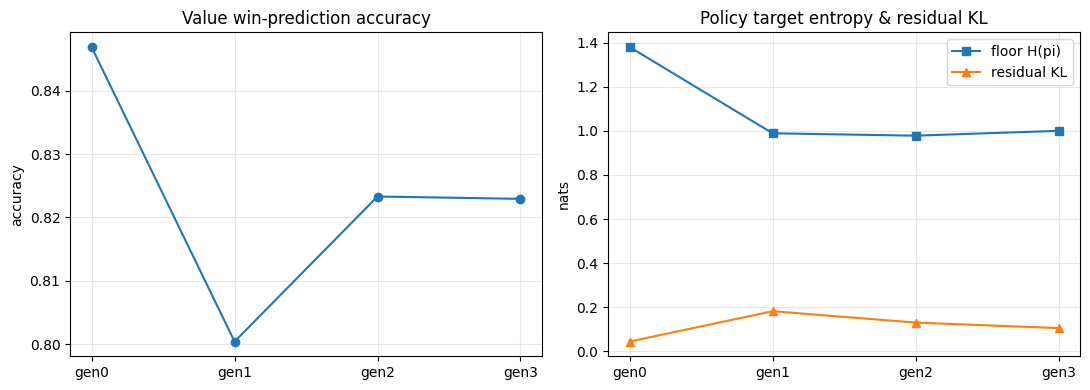

In [8]:
rows = [gen0, gen1, gen2, gen3]
names = [g["name"] for g in rows]
x = list(range(len(rows)))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, [g["value_acc"] for g in rows], marker="o", color="#1f77b4")
ax[0].set_xticks(x); ax[0].set_xticklabels(names); ax[0].set_ylabel("accuracy")
ax[0].set_title("Value win-prediction accuracy"); ax[0].grid(alpha=.3)
ax[1].plot(x, [g["floor"] for g in rows], marker="s", label="floor H(pi)")
ax[1].plot(x, [g["kl"] for g in rows], marker="^", label="residual KL")
ax[1].set_xticks(x); ax[1].set_xticklabels(names); ax[1].set_ylabel("nats")
ax[1].set_title("Policy target entropy & residual KL"); ax[1].grid(alpha=.3); ax[1].legend()
fig.tight_layout(); plt.show()